# APS360 Project — Primary Model (CNN)


## 1. Mount Drive and unzip the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, zipfile, time, shutil, glob

ZIP_PATH  = '/content/drive/MyDrive/data.zip'
EDM_ZIP   = '/content/drive/MyDrive/edmonton.zip'
NEW_LABEL = '/content/drive/MyDrive/labels.csv'
WORK = '/content/data'

assert os.path.exists(ZIP_PATH), f'Could not find {ZIP_PATH}.'

if not os.path.exists(WORK):
    t0 = time.time()
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(WORK)
    print(f'Unzipped 5-city data in {time.time()-t0:.0f}s')
else:
    print('5-city data already unzipped.')

IMG_DIR, LABELS = None, None
for root, dirs, files in os.walk(WORK):
    if 'labels.csv' in files:
        LABELS = os.path.join(root, 'labels.csv')
    if os.path.basename(root) == 'images':
        IMG_DIR = root
assert IMG_DIR and LABELS, 'Zip structure unexpected.'


n_before = len(glob.glob(os.path.join(IMG_DIR, 'edmonton_*.png')))
if n_before == 0:
    assert os.path.exists(EDM_ZIP), f'Could not find {EDM_ZIP} in My Drive.'
    with zipfile.ZipFile(EDM_ZIP) as z:
        z.extractall(IMG_DIR)

    for p in glob.glob(os.path.join(IMG_DIR, '**', 'edmonton_*.png'), recursive=True):
        if os.path.dirname(p) != IMG_DIR:
            shutil.move(p, os.path.join(IMG_DIR, os.path.basename(p)))
    print('Extracted Edmonton images.')

assert os.path.exists(NEW_LABEL), f'Could not find {NEW_LABEL} in My Drive.'
shutil.copy(NEW_LABEL, LABELS)

print('images dir :', IMG_DIR)
print('labels csv :', LABELS)
print('edmonton PNGs on disk:', len(glob.glob(os.path.join(IMG_DIR, 'edmonton_*.png'))))

import pandas as pd
_chk = pd.read_csv(LABELS)
print(_chk.split.value_counts().to_string())
assert (_chk.split == 'test').sum() > 0, 'labels.csv has no test rows - wrong file?'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
5-city data already unzipped.
images dir : /content/data/images
labels csv : /content/data/labels.csv
edmonton PNGs on disk: 638
split
train    2084
test      614
val       404


## 2. Dataset


In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

HEADS = ['density_rating', 'connectivity_rating', 'green_rating']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([

    T.RandomResizedCrop(384, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomChoice([
        T.RandomRotation((0, 0)),
        T.RandomRotation((90, 90)),
        T.RandomRotation((180, 180)),
        T.RandomRotation((270, 270)),
    ]),

    T.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.20, hue=0.02),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_tf = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class TileDataset(Dataset):
    def __init__(self, df, img_dir, tf):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.tf = tf
    def __len__(self):
        return len(self.df)
    def __getitem__(self, i):
        row = self.df.iloc[i]
        img = Image.open(os.path.join(self.img_dir, row.tile_id + '.png')).convert('RGB')
        x = self.tf(img)

        y = torch.tensor([int(row[h]) - 1 for h in HEADS], dtype=torch.long)
        return x, y

df = pd.read_csv(LABELS)
train_df = df[df.split == 'train'].copy()
val_df   = df[df.split == 'val'].copy()
print(f'train tiles: {len(train_df)}   val tiles: {len(val_df)}')

BATCH = 16
train_loader = DataLoader(TileDataset(train_df, IMG_DIR, train_tf),
                          batch_size=BATCH, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(TileDataset(val_df, IMG_DIR, eval_tf),
                          batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

train tiles: 2084   val tiles: 404


In [ ]:
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


## 3. Model — ResNet-18 backbone + three MLP heads


In [ ]:
import torch.nn as nn
from torchvision import models

class MultiHeadResNet(nn.Module):
    def __init__(self, n_classes=3, n_heads=3, p_drop=0.5):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        self.features = nn.Sequential(*list(backbone.children())[:-1])
        self.embed_dim = backbone.fc.in_features


        for name, child in zip(
                ['conv1','bn1','relu','maxpool','layer1','layer2','layer3','layer4','avgpool'],
                self.features):
            requires = name in ('layer4',)
            for p in child.parameters():
                p.requires_grad = requires

        def make_head():
            return nn.Sequential(
                nn.Linear(self.embed_dim, 128), nn.ReLU(),
                nn.Dropout(p_drop), nn.Linear(128, n_classes))
        self.heads = nn.ModuleList([make_head() for _ in range(n_heads)])

    def forward(self, x):
        z = self.features(x).flatten(1)
        return [head(z) for head in self.heads]

model = MultiHeadResNet().to(device)

total = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total:,}')
print(f'Trainable parameters: {train_params:,}')
print(f'Frozen parameters:    {total - train_params:,}')

Total parameters:     11,374,665
Trainable parameters: 8,591,881
Frozen parameters:    2,782,784


## 4. Training


In [ ]:
EPOCHS = 15
criterion = nn.CrossEntropyLoss()

backbone_params = [p for p in model.features.parameters() if p.requires_grad]
head_params = [p for p in model.heads.parameters()]
optimizer = torch.optim.Adam([
    {'params': backbone_params, 'lr': 1e-4},
    {'params': head_params,     'lr': 1e-3},
], weight_decay=1e-4)   # L2 regularisation (Lecture 3)

def run_epoch(loader, train):
    model.train() if train else model.eval()
    tot_loss, correct, count = 0.0, np.zeros(len(HEADS)), 0
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outs = model(x)
        loss = sum(criterion(outs[h], y[:, h]) for h in range(len(HEADS)))
        if train:
            optimizer.zero_grad(); loss.backward(); optimizer.step()
        tot_loss += loss.item() * x.size(0)
        for h in range(len(HEADS)):
            correct[h] += (outs[h].argmax(1) == y[:, h]).sum().item()
        count += x.size(0)
    return tot_loss / count, (correct / count)

hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val = 0.0
for ep in range(1, EPOCHS + 1):
    tl, ta = run_epoch(train_loader, True)
    vl, va = run_epoch(val_loader, False)
    hist['train_loss'].append(tl); hist['val_loss'].append(vl)
    hist['train_acc'].append(ta.mean()); hist['val_acc'].append(va.mean())
    if va.mean() > best_val:
        best_val = va.mean(); torch.save(model.state_dict(), '/content/best_model_384.pt')
    print(f'epoch {ep:2d}  train_loss {tl:.3f}  val_loss {vl:.3f}  '
          f'train_acc {ta.mean():.3f}  val_acc {va.mean():.3f}  '
          f'[d {va[0]:.2f} c {va[1]:.2f} g {va[2]:.2f}]')
print(f'\nBest mean val accuracy: {best_val:.3f} (saved to best_model.pt)')

epoch  1  train_loss 2.605  val_loss 2.333  train_acc 0.578  val_acc 0.640  [d 0.72 c 0.60 g 0.60]
epoch  2  train_loss 2.210  val_loss 2.065  train_acc 0.659  val_acc 0.691  [d 0.77 c 0.65 g 0.65]
epoch  3  train_loss 2.133  val_loss 1.957  train_acc 0.669  val_acc 0.715  [d 0.80 c 0.67 g 0.67]
epoch  4  train_loss 2.027  val_loss 1.925  train_acc 0.690  val_acc 0.720  [d 0.83 c 0.67 g 0.66]
epoch  5  train_loss 1.965  val_loss 2.010  train_acc 0.706  val_acc 0.705  [d 0.80 c 0.66 g 0.66]
epoch  6  train_loss 1.892  val_loss 1.875  train_acc 0.718  val_acc 0.720  [d 0.82 c 0.68 g 0.66]
epoch  7  train_loss 1.890  val_loss 1.851  train_acc 0.717  val_acc 0.734  [d 0.80 c 0.69 g 0.71]
epoch  8  train_loss 1.851  val_loss 1.974  train_acc 0.717  val_acc 0.711  [d 0.80 c 0.68 g 0.65]
epoch  9  train_loss 1.808  val_loss 1.887  train_acc 0.726  val_acc 0.713  [d 0.81 c 0.66 g 0.67]
epoch 10  train_loss 1.769  val_loss 1.989  train_acc 0.739  val_acc 0.703  [d 0.78 c 0.69 g 0.65]
epoch 11  

In [ ]:
import shutil, os
os.makedirs('/content/drive/MyDrive/aps360_outputs', exist_ok=True)
shutil.copy('/content/best_model.pt', '/content/drive/MyDrive/aps360_outputs/best_model_224.pt')
print('backed up')

backed up


## 5. Training curves

Loss and mean accuracy, training vs. validation, per epoch. Saved as PNGs for the report.

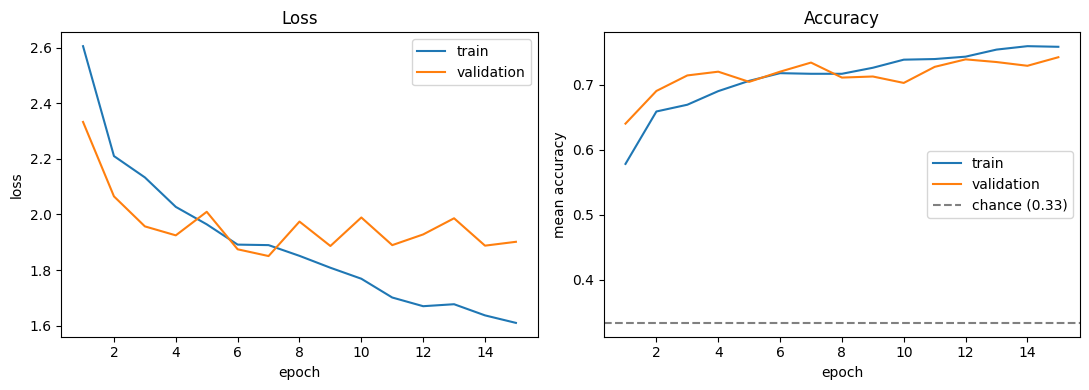

Saved /content/training_curves.png


In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(hist['train_loss']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.plot(epochs, hist['train_loss'], label='train')
ax1.plot(epochs, hist['val_loss'], label='validation')
ax1.set_xlabel('epoch'); ax1.set_ylabel('loss'); ax1.set_title('Loss'); ax1.legend()

ax2.plot(epochs, hist['train_acc'], label='train')
ax2.plot(epochs, hist['val_acc'], label='validation')
ax2.axhline(1/3, ls='--', c='gray', label='chance (0.33)')
ax2.set_xlabel('epoch'); ax2.set_ylabel('mean accuracy'); ax2.set_title('Accuracy'); ax2.legend()

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved /content/training_curves.png')

## 6. Save outputs to Drive


In [ ]:
import shutil, os
out = '/content/drive/MyDrive/aps360_outputs'
os.makedirs(out, exist_ok=True)
for f in ['best_model_384.pt', 'training_curves.png',
          'confusion_matrices.png', 'qualitative_grid.png', 'results.txt']:
    p = '/content/' + f
    if os.path.exists(p):
        shutil.copy(p, out); print('saved', f)
    else:
        print('MISSING:', f)
print('\n->', out)

saved best_model_384.pt
saved training_curves.png
MISSING: confusion_matrices.png
MISSING: qualitative_grid.png
MISSING: results.txt

-> /content/drive/MyDrive/aps360_outputs


## 7. Held-out test: Edmonton


In [ ]:
import numpy as np, pandas as pd, torch

df_all  = pd.read_csv(LABELS)
test_df = df_all[df_all.split == 'test'].copy()
print(f'test tiles: {len(test_df)}  cities: {sorted(test_df.city.unique())}')

test_loader = DataLoader(TileDataset(test_df, IMG_DIR, eval_tf),
                         batch_size=16, shuffle=False, num_workers=2)

model.load_state_dict(torch.load('/content/best_model_384.pt', map_location=device))
model.eval()

preds, trues = [], []
with torch.no_grad():
    for x, y in test_loader:
        outs = model(x.to(device))
        preds.append(torch.stack([o.argmax(1).cpu() for o in outs], 1))
        trues.append(y)
preds = torch.cat(preds).numpy()
trues = torch.cat(trues).numpy()

train_df_all = df_all[df_all.split == 'train']
lines = [f'Held-out city: Edmonton, n = {len(test_df)}', '',
         f"{'category':14s}{'acc':>8s}{'majority':>10s}{'chance':>8s}{'MAE':>8s}{'within-1':>10s}"]
for h, name in enumerate(HEADS):
    p, t = preds[:, h], trues[:, h]
    maj_class = train_df_all[name].mode()[0] - 1      # most common TRAIN class
    lines.append(f'{name.replace("_rating",""):14s}'
                 f'{(p==t).mean():8.3f}{(t==maj_class).mean():10.3f}{0.333:8.3f}'
                 f'{np.abs(p-t).mean():8.3f}{(np.abs(p-t)<=1).mean():10.3f}')
print('\n'.join(lines))

test tiles: 614  cities: ['edmonton']
Held-out city: Edmonton, n = 614

category           acc  majority  chance     MAE  within-1
density          0.697     0.316   0.333   0.306     0.997
connectivity     0.718     0.298   0.333   0.287     0.995
green            0.728     0.414   0.333   0.345     0.927


### Confusion matrices

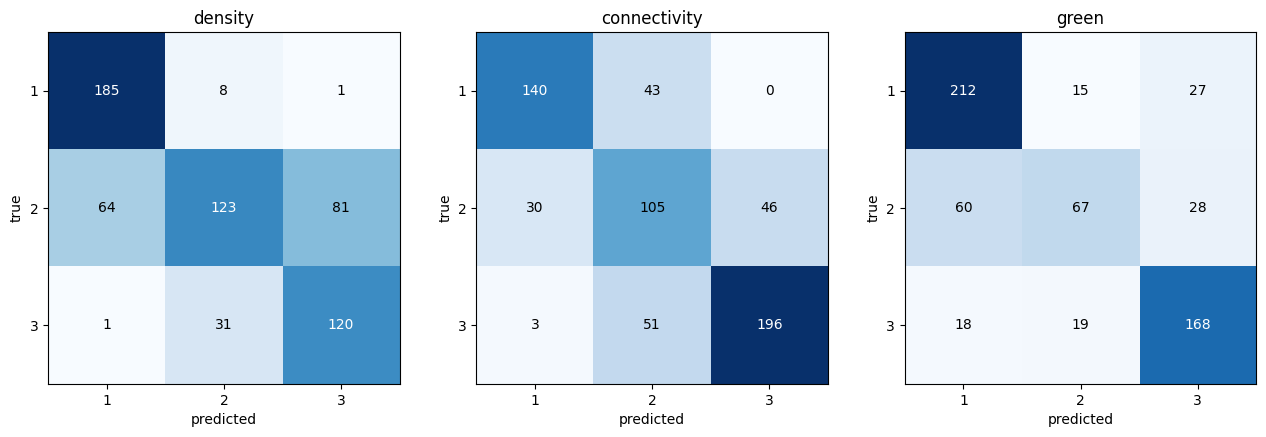

In [ ]:
import matplotlib.pyplot as plt

cms = []
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
for h, (name, ax) in enumerate(zip(HEADS, axes)):
    cm = np.zeros((3, 3), int)
    for t, p in zip(trues[:, h], preds[:, h]):
        cm[t, p] += 1
    cms.append(cm)
    ax.imshow(cm, cmap='Blues')
    for a in range(3):
        for b in range(3):
            ax.text(b, a, cm[a, b], ha='center', va='center',
                    color='white' if cm[a, b] > cm.max()*0.6 else 'black')
    ax.set_xticks(range(3)); ax.set_xticklabels([1, 2, 3])
    ax.set_yticks(range(3)); ax.set_yticklabels([1, 2, 3])
    ax.set_xlabel('predicted'); ax.set_ylabel('true')
    ax.set_title(name.replace('_rating', ''))
    lines += [f'{name} confusion (rows=true, cols=pred):', str(cm), '']
plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### Qualitative results


Worst category: density. Failures drawn from true=2, predicted=3 (largest off-diagonal cell, n=81).


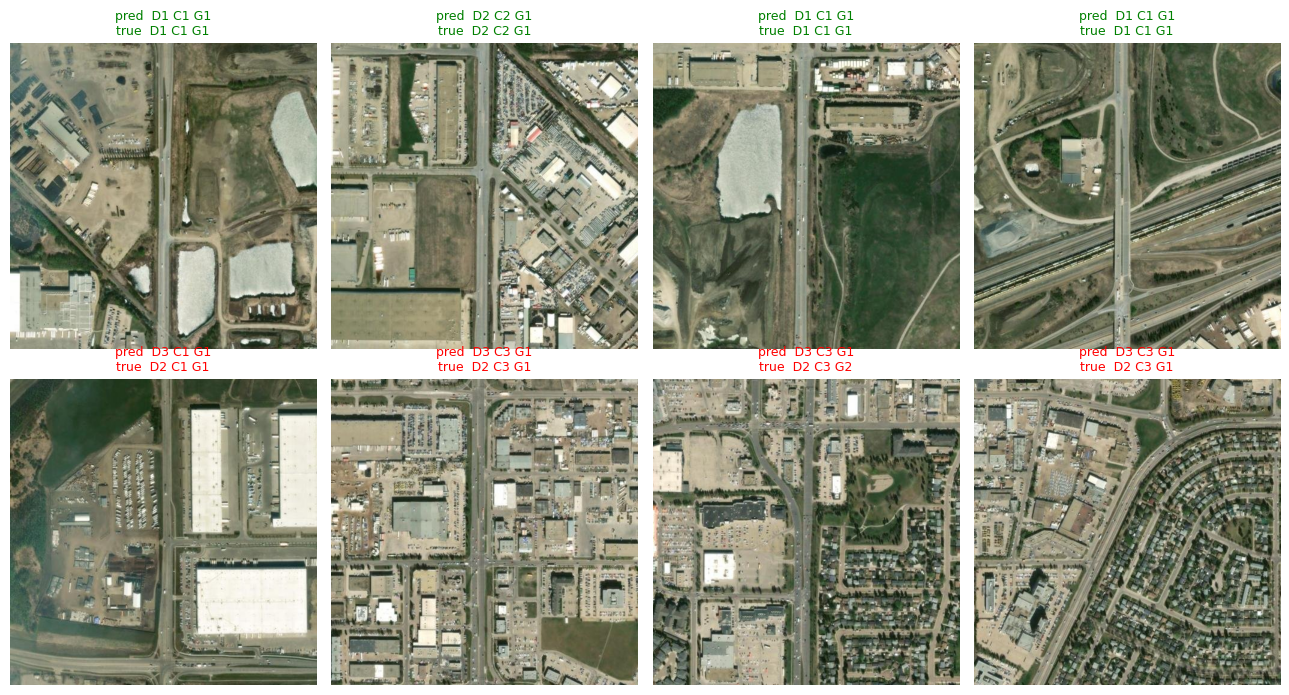


wrote /content/results.txt


In [ ]:
from PIL import Image

worst = int(np.argmin([(preds[:, h] == trues[:, h]).mean() for h in range(3)]))
cm = cms[worst].copy(); np.fill_diagonal(cm, 0)
ti, pi = np.unravel_index(cm.argmax(), cm.shape)
ok  = np.where(preds[:, worst] == trues[:, worst])[0][:4]
bad = np.where((trues[:, worst] == ti) & (preds[:, worst] == pi))[0][:4]

caption = (f"Worst category: {HEADS[worst].replace('_rating','')}. "
           f"Failures drawn from true={ti+1}, predicted={pi+1} "
           f"(largest off-diagonal cell, n={cm.max()}).")
print(caption)
lines += ['', caption]

td = test_df.reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(13, 7))
for ax, idx in zip(axes.ravel(), list(ok) + list(bad)):
    row = td.iloc[idx]
    ax.imshow(Image.open(os.path.join(IMG_DIR, row.tile_id + '.png')).convert('RGB'))
    p = [preds[idx, k] + 1 for k in range(3)]
    t = [trues[idx, k] + 1 for k in range(3)]
    ax.set_title(f'pred  D{p[0]} C{p[1]} G{p[2]}\ntrue  D{t[0]} C{t[1]} G{t[2]}',
                 fontsize=9, color='green' if p[worst] == t[worst] else 'red')
    ax.axis('off')
plt.tight_layout()
plt.savefig('/content/qualitative_grid.png', dpi=150, bbox_inches='tight')
plt.show()

with open('/content/results.txt', 'w') as f:
    f.write('\n'.join(lines))
print('\nwrote /content/results.txt')

## 8. Save every report artefact to Drive

In [ ]:
import shutil
out = '/content/drive/MyDrive/aps360_outputs'
os.makedirs(out, exist_ok=True)
for f in ['best_model_384.pt', 'training_curves.png',
          'confusion_matrices.png', 'qualitative_grid.png', 'results.txt']:
    p = '/content/' + f
    if os.path.exists(p):
        shutil.copy(p, out); print('saved', f)
print('\nAll outputs ->', out)

saved best_model_384.pt
saved training_curves.png
saved confusion_matrices.png
saved qualitative_grid.png
saved results.txt

All outputs -> /content/drive/MyDrive/aps360_outputs
